# Lab 8 - Sensor Fusion

Following this week's lecture, we are going to implement three fusion techniques:
1.   Simple averaging
2.   Weighted fusion
3.   Kalman Filtering

In this lab, we are going to:
1.   Simulate a true signal of motion (hidden state)
2.   Simulate two sensors that aim to estimate the hidden state with different types of failure. A GPS (noisy, no drift) and an IMU (smooth but drifts over time).
3.   Implement averaging, weighted, and Kalman Filter fusion techniques.
4.   Compare each approach using the Root Mean Squared Error (RMSE). Unlike accuracy, precision, recall, and F1 score, lower RMSE is better!

**Our goal is to estimate the hidden true state of the environment.**

There are no major challenges this week, and any remaining time should be spent working on your coursework. By this point, you should have a good idea of the dataset and types you wish to use, ensure you make the most of this time to speak with your tutor for feedback or about potential solutions to your chosen problem!

First we will set up our environment...





In [ ]:
!pip install numpy matplotlib filterpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=21a7ddb8f5182554ffb38e8aea88da35815dfe6ec8169a590e1e35ced9bf212a
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from filterpy.kalman import KalmanFilter

# Today we are going to use the random number generator for synthetic noise. This ensures the same "random" noise is generated each time.
rng = np.random.default_rng(42)

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True

# Part 1 - Simulating the Hidden State (Reality)

Now we will set up our true hidden state. Our hidden state describes an object in motion which will have a position (metres), velocity (metres per second), and acceleration (metres per second squared).

In [ ]:
dt = 0.1 # Delta time, how many seconds pass between each step
T = 40.0 # The total time we are going to simulate
t = np.arange(0, T + dt, dt) # Time intervals from 0, 0.1, 0.2 etc. to 40, dictated by delta time
n = len(t) # n will be used later, this is the number of time points we measure

# These will be our ground truth arrays
# Filled with zeroes for now, we'll populate them afterwards.

x_true = np.zeros(n)  # position (measured in metres)
v_true = np.zeros(n)  # velocity (measured in metres per second, m/s)
a_true = np.zeros(n)  # acceleration (measured in metres per second squared, m/s^2)

First we will populate the acceleration of the object. Rather than it being completely uniform, we'll define some simple rules so the acceleration changes over time.

In [ ]:
for i, ti in enumerate(t):
    if 0 <= ti < 10:
        a_true[i] = 0.25
    elif 10 <= ti < 20:
        a_true[i] = -0.15
    elif 20 <= ti < 30:
        a_true[i] = 0.10
    else:
        a_true[i] = 0.0

Now that we know the true acceleration, we can quickly calculate the velocity and location of the object.

Note: this is extremely simplified and not entirely physically accurate, however, these values will work fine for our excercise.

In [ ]:
for k in range(1, n):
    v_true[k] = v_true[k-1] + a_true[k-1] * dt # previous velocity plus accel*time
    x_true[k] = x_true[k-1] + v_true[k-1] * dt # calculate the location, simplified as old position plus velocity*time

**Let's visualise it!**

The below code will visualise how far away our object is from the origin.

Note: in practice, we will never know these values (ergo the "hidden" state). As we discussed this week, sensors will only produce estimates that contain noise and/or uncertainty, and the hidden state can never be truly observed.

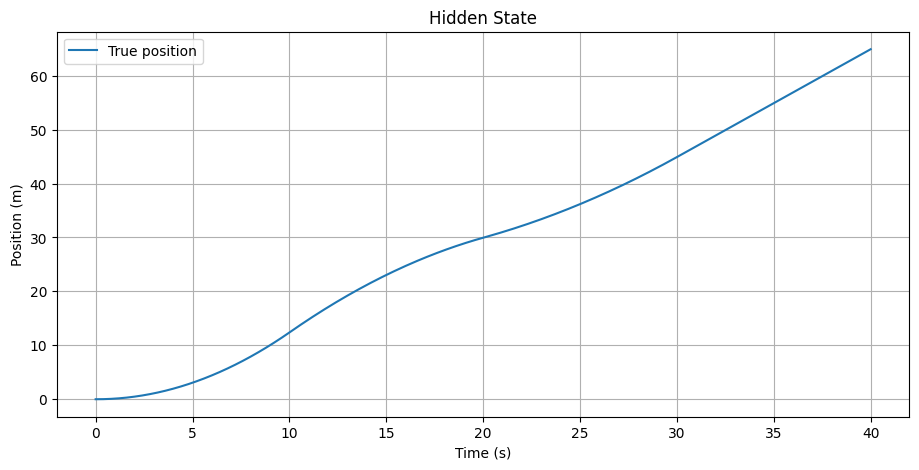

In [ ]:
plt.plot(t, x_true, label="True position")
plt.title("Hidden State")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.legend()
plt.show()

# Part 2 - Simulating a GPS signal

Now we will simulate a GPS aiming to track the object. Remember, GPS has a random noise but does **not** drift.

We will assume a standard deviation of 2.5 metres in the resolution of the GPS.

Note: under normal conditions, GPS has an inaccuracy of around 1 to 10 metres.

**Point of reflection** - imagine relying on only GPS in a car. Could this level of accuracy cause serious problems?

If you have ever missed a turning, your GPS will often display the vehicle not missing it and continuing as normal. Why? Sensor fusion expected you to travel there!

In [ ]:
gps_sigma = 2.5  # standard deviation set to 2.5 metres metres
gps_pos = x_true + rng.normal(0, gps_sigma, size=n) # here we use the std dev of 2.5 to generate some random noise.

# Part 3 - Simulating an Inertial Measurement Unit (IMU)

This is a little more complicated than the GPS simulation.

**Why is that?** A GPS only measures location, whereas our IMU will measure acceleration.

To do this, we will implement a simple simulation of noise and drift.

Question: is drift an example of cumulative error? i.e., Does error compound over time?

In [ ]:
imu_sigma = 0.12 # Noise in the acceleration, AKA 0.12 m/s^2
bias_random_walk_sigma = 0.01 # Dictates how quickly the drift over time

imu_bias = np.zeros(n) # To reference for the bias at each time step
for k in range(1, n):
    imu_bias[k] = imu_bias[k-1] + rng.normal(0, bias_random_walk_sigma) # Populate bias at each time step

imu_acc = a_true + imu_bias + rng.normal(0, imu_sigma, size=n) # Using the above, we will now calculate the acceleration reading at each timestep. This is the true value, the bias, and some random noise too.

# IMPORTANT
# Note that in real-world conditions, we will not have access to "a_true"!


# Now we can use the previous calculations to update each of the velocity and position values
imu_vel = np.zeros(n)
imu_pos = np.zeros(n)
for k in range(1, n):
    imu_vel[k] = imu_vel[k-1] + imu_acc[k-1] * dt
    imu_pos[k] = imu_pos[k-1] + imu_vel[k-1] * dt

# Visualisation

Now let's visualise our predictions.

**Points of reflection**
1.   Which sensor is better short-term? The first 5 seconds
2.   Which sensor is better long-term?
3.   **Why?** Ensure you use the words "drift" and "noise" in your answer.



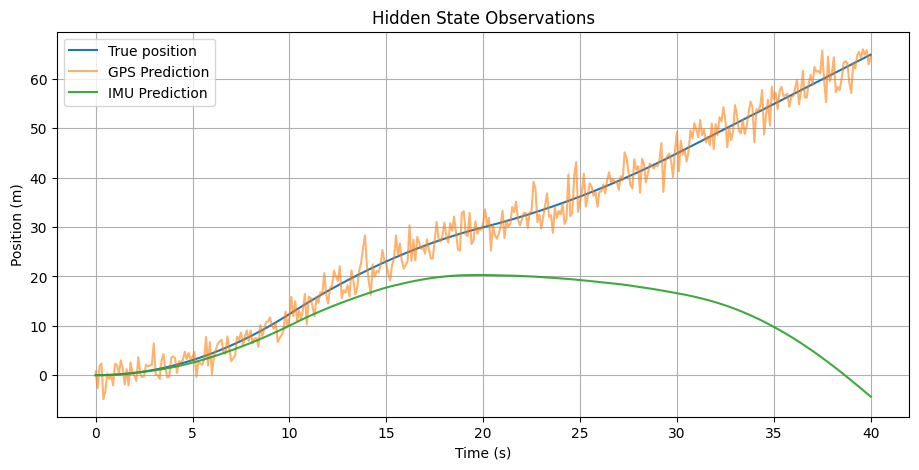

In [ ]:
plt.plot(t, x_true, label="True position")
plt.plot(t, gps_pos, label="GPS Prediction", alpha=0.6)
plt.plot(t, imu_pos, label="IMU Prediction", alpha=0.9)
plt.title("Hidden State Observations")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.legend()
plt.show()

# Part 4 - Fusion Techniques

Okay, now we have three sets of values. The true state, the GPS prediction, and the IMU prediction.

We have a tradeoff. IMU is very accurate short-term, but drift has reduced accuracy quite quickly. The GPS is quite accurate long-term, but suffers from noise.

At this stage, both signals are not very helpful...

However, their errors (or failure modes) differ. That is, the two sensors could compliment one another.


---


First, we will define our scoring function as **Root Mean Squared Error**. RMSE is measured in readable units, in this case, it is the error in metres.

RMSE can be used as an alternative scoring function in Machine Learning. This is a regression problem, meaning that our model is predicting a real numerical value.

More on that here for statistical learning approaches: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html

And for Deep Learning: https://www.tensorflow.org/api_docs/python/tf/keras/metrics/RootMeanSquaredError

**Note: these two pages are describing the same thing.**



In [ ]:
def rmse(true, pred):
    return np.sqrt(np.mean((true - pred)**2))

# Simple Averaging Fusion

Simple fusion is easy to implement, especially with two sensors. We will just set equal weights of 0.5 for each.

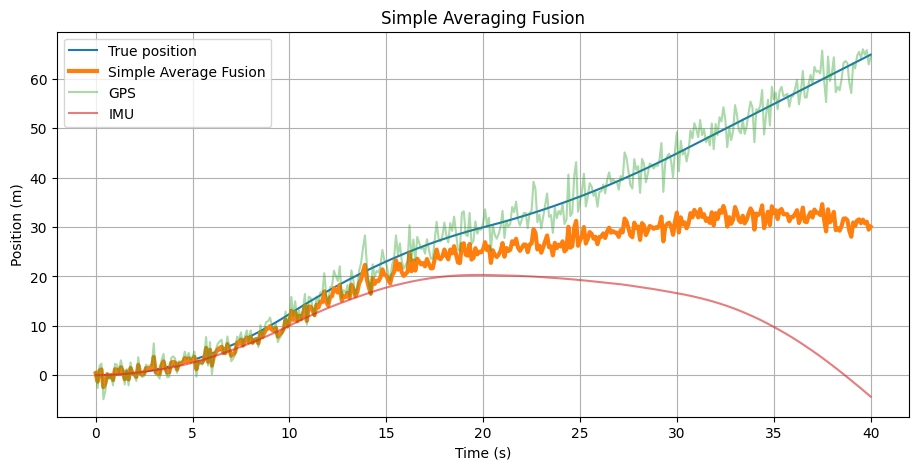

Average fusion RMSE = 12.979 metres of error


In [ ]:
avg_pos = 0.5 * gps_pos + 0.5 * imu_pos

plt.plot(t, x_true, label="True position")
plt.plot(t, avg_pos, label="Simple Average Fusion", linewidth=3)
plt.plot(t, gps_pos, label="GPS", alpha=0.4)
plt.plot(t, imu_pos, label="IMU", alpha=0.6)
plt.title("Simple Averaging Fusion")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.legend()
plt.show()

print(f"Average fusion RMSE = {rmse(x_true, avg_pos):.3f} metres of error")

# Weighted Fusion

Similarly to our thermostats in the lecture, is there one sensor we trust more than the other overall? If so, we should weight that moreso than the other.

**Task:** explore different values of weights by changing "w_gps".

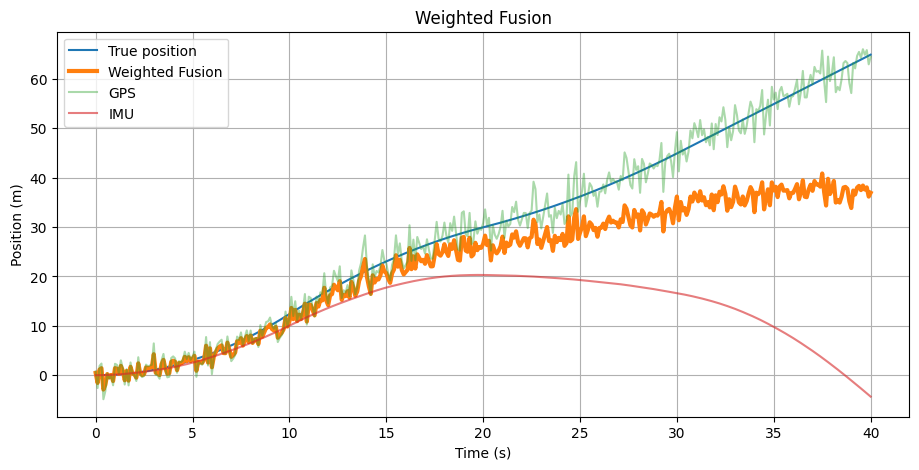

Average fusion RMSE = 10.427 metres of error


In [ ]:
w_gps = 0.6 # change this value





w_imu = 1 - w_gps # calculate the IMU weight
w_pos = w_gps * gps_pos + w_imu * imu_pos
plt.plot(t, x_true, label="True position")
plt.plot(t, w_pos, label="Weighted Fusion", linewidth=3)
plt.plot(t, gps_pos, label="GPS", alpha=0.4)
plt.plot(t, imu_pos, label="IMU", alpha=0.6)
plt.title("Weighted Fusion")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.legend()
plt.show()

print(f"Average fusion RMSE = {rmse(x_true, w_pos):.3f} metres of error")

# Kalman Filtering

Implementing Kalman Filtering is complex, and you can read about that here: https://filterpy.readthedocs.io/en/latest/kalman/KalmanFilter.html

Thankfully, the FilterPy library (among many others) have Kalman filters built-in. There are also other filters available, as well as variants of the Klaman filter.

Note this excerpt from the documentation:
> *Instance Variables*

> *You will have to assign reasonable values to all of these before running the filter.*

Thinking back to our labs on hand-crafted features, this is the signal fusion equivalent. We **have to make assumptions** before implementing the approach...

Kalman Filtering will estimate the position and velocity, with the filter state being [position, velocity] (two dimensions).


**Note:** the below implements each step of the Kalman Filter algorithm which we went through one-by-one in the lecture.


In [ ]:
kf = KalmanFilter(dim_x=2, dim_z=1)

# The state transition matrix
# We need to take [position, velocity] at the current time and change it to [position, velocity] at time+1
kf.F = np.array([[1, dt],
                 [0, 1]])

# The measurement function
# We only have one value here (position) because GPS does not measure velocity.
kf.H = np.array([[1, 0]])

# Initial state
# Simply, the first GPS measurement with no velocity, assume stationary
kf.x = np.array([gps_pos[0], 0.0])

# Initial uncertainty
# This value would normally be influenced by the manufacturer stats for a signal
# Larger values mean less initial confidence
kf.P *= 10.0

# Measurement noise (as above re: manufacturer stats)
# WWe'll just assume gps standard deviation squared
kf.R = np.array([[gps_sigma**2]])

# Process noise
# How imperfect the motion model is... we'll keep this simple!
kf.Q = np.array([[0.1, 0.0],
                 [0.0, 0.1]])


# Now to use all those hyperparameters to calculate each prediction!
kalman_pos = np.zeros(n)

for k in range(n):
    kf.predict() # predict the next state, the KF object holds this for us (which is why we don't have a variable assignment here)

    kf.update(gps_pos[k]) # Update with a GPS measurement

    kalman_pos[k] = kf.x[0] # Extract the estimation and store it

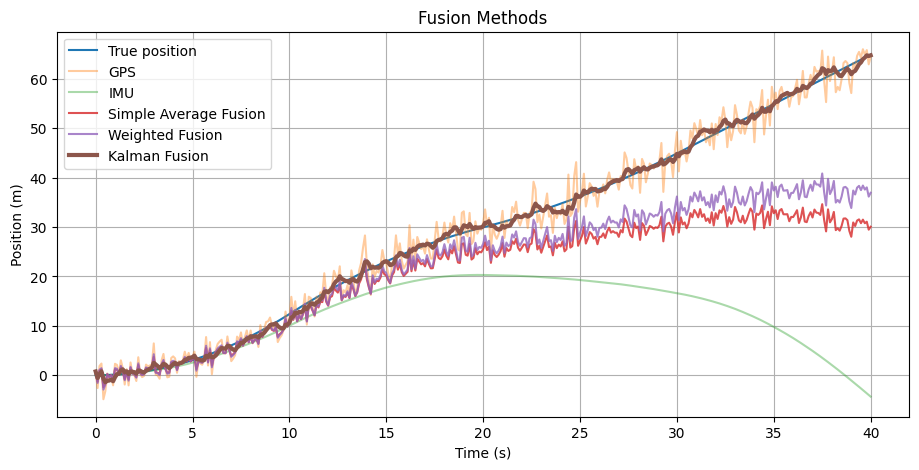

Kalman RMSE = 0.826 m


In [ ]:
plt.plot(t, x_true, label="True position")
plt.plot(t, gps_pos, label="GPS", alpha=0.4)
plt.plot(t, imu_pos, label="IMU", alpha=0.4)
plt.plot(t, avg_pos, label="Simple Average Fusion", alpha=0.8)
plt.plot(t, w_pos, label="Weighted Fusion", alpha=0.8)
plt.plot(t, kalman_pos, label="Kalman Fusion", linewidth=3)
plt.title("Fusion Methods")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.legend()
plt.show()

print(f"Kalman RMSE = {rmse(x_true, kalman_pos):.3f} m")

# Summarising the Results

The below code will bring together all of our results. Which performed best?

**Was sensor fusion worth it?**

In [ ]:
results = {
    "GPS Sensor": rmse(x_true, gps_pos),
    "IMU Sensor": rmse(x_true, imu_pos),
    "Average Fusion": rmse(x_true, avg_pos),
    "Weighted Fusion": rmse(x_true, w_pos),
    "Kalman Fusion": rmse(x_true, kalman_pos),
}

for name, score in sorted(results.items(), key=lambda kv: kv[1]):
    print(f"{name:28s} RMSE = {score:.3f} metres of error")

Kalman Fusion                RMSE = 0.826 metres of error
GPS Sensor                   RMSE = 2.375 metres of error
Weighted Fusion              RMSE = 10.427 metres of error
Average Fusion               RMSE = 12.979 metres of error
IMU Sensor                   RMSE = 25.900 metres of error


# Your Task

You have a choice of tasks today:
1.   Continue working on this lab
2.   Continue working on your coursework


---


**Continue working on this lab**

Explore decreasing the accuracy of GPS. In this scenario, we will reimagine our position as altitude, i.e., if we are tracking a flying object such as a helicopter.

GPS is **far less** accurate when calculating altitude, often tens of metres. Go back through the lab and change the GPS error as follows:
```
gps_sigma = 10.0
```

Aircraft will also have **much better** (and more expensive!) IMU sensors. Upgrade your IMU by lowering the noise and drift rate as follows:
```
bias_random_walk_sigma = 0.03
bias_random_walk_sigma = 0.004
```

Using these values, run through the notebook again to explore the best fusion techniques to calculate the altitude of the flying object.



---



**Continue working on your coursework**

You may also use this time to work on your coursework. Ensure that you speak to your tutor regarding dataset choice before moving on.

